<div style="
background-color:#EAEAEA;
padding:20px;
border-left:5px solid #6C757D;
border-radius:6px;">

<table style="width:100%; border:none;">
<tr style="border:none;">

<td style="border:none; vertical-align:top;">

<h1 style="font-size:32px; margin-top:0;">
Master's Thesis
</h1>

<hr style="margin:16px 0 22px 0;">

<p style="font-size:22px; line-height:1.5; margin:0;">
<strong>Master's Degree in Advanced Physics</strong> - 
<strong>Universitat de Val?ncia</strong>
</p>

<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">
This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:
</p>

<div style="
font-size:25px;
font-weight:700;
line-height:1.3;
margin-top:14px;
margin-bottom:26px;">
Fast Simulation of Neutrino Oscillations in Matter
</div>

<p style="font-size:14px; line-height:1.55;">
<strong>Author</strong><br>
Juan Ramon Diaz Santos - 
<a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a>
</p>

<p style="font-size:14px; line-height:1.55;">
<strong>Supervisors</strong><br>
Roberto Ruiz de Austri Bazan ?
<a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>
Michele Lucente ?
<a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a>
</p>

<p style="font-size:14px; line-height:1.55; margin-bottom:0;">
<strong>Date</strong><br>
September 2026
</p>

</td>

<td style="
border:none;
width:230px;
padding-left:25px;
text-align:right;
vertical-align:top;">

<img src="../../../logo_uv.png"
     alt="Universitat de Val?ncia"
     style="width:200px; margin-top:5px;">

</td>

</tr>
</table>

</div>

# BSM Analysis — Sterile Neutrino (3+1): Two-Flavour Approximation and the L/E Landscape
---

Second notebook of the 3+1 sterile-neutrino series. `sterile1_test.ipynb` verifies that
the `PMNS_sterile`/BSM Hamiltonian implementation is mathematically correct (SM limit,
unitarity, Hamiltonian structure, CP structure). This notebook asks a different
question: **when is the standard textbook 2-flavour disappearance formula a good
approximation to the full 4-flavour numerics, and where do real short/long-baseline
experiments sit in the $(L,E)$ plane?** It provides the definitions, experiment
characteristics, and theoretical-prediction formulae (with their validity ranges) used
throughout the series, then validates the 2-flavour approximation in two steps: first
in an idealized limit where it is provably exact, then at the realistic mixing angles
used elsewhere in the series, quantifying precisely how and why it deviates.
`sterile3_analysis.ipynb` then confronts the model with real experimental data.

---

## Table of Contents

| # | Section |
|---|---------|
| [0](#0.-Theory-Background) | **Theory Background** — definitions, experiments, predictions, approximation validity |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Configuration** — paths, presets, helpers |
| [3](#3.-Exact-Two-Flavour-Limit) | **Exact Two-Flavour Limit** — a preset where the textbook formula is provably exact |
| [4](#4.-Two-Flavour-Approximation-at-Realistic-Mixing) | **Realistic Mixing** — quantified deviation for Giunti 2017 / IceCube 2020 |
| [5](#5.-L/E-Sensitivity-Window) | **L/E Window** — oscillation patterns and where experiments sit |
| [∑](#Summary) | **Summary** |

## 0. Theory Background

### 0.1 Definitions

**Oscillation phase.** For two mass eigenstates $i,j$ with squared-mass difference
$\Delta m^2_{ij}=m_i^2-m_j^2$ (eV$^2$), propagating a baseline $L$ (km) at energy $E$
(GeV), the standard oscillation phase is

$$\Delta_{ij} \equiv 1.267\,\frac{\Delta m^2_{ij}\,[\text{eV}^2]\;L\,[\text{km}]}{E\,[\text{GeV}]}
\qquad\text{(equivalently } 1.267\times10^{3}\,\Delta m^2_{ij}\,L[\text{km}]/E[\text{MeV}]\text{)}.$$

The constant $1.267$ is a rounded, commonly quoted approximation to the exact value
$\hbar c/(4)\times(\text{unit conversions}) = 1.26693\ldots$ derived from $\hbar c$
(see `tpeanuts.util.constant.HBARC_MeV_m`); the rounding is harmless for order-of-magnitude
estimates but becomes visible after enough oscillation periods have accumulated
(quantified in Section 3).

**Disappearance vs. appearance.** A *disappearance* channel measures
$P(\nu_\alpha\to\nu_\alpha)$ (survival); an *appearance* channel measures
$P(\nu_\alpha\to\nu_\beta)$, $\alpha\neq\beta$. 
- Reactor, Gallium, and IceCube below are disappearance searches.
- LSND and MiniBooNE are appearance searches.

**Short-baseline (SBL) regime.** Historically denotes $L\lesssim$ a few hundred metres to
a few km at $E\sim$ MeV–GeV, where an eV$^2$-scale $\Delta m^2_{41}$ produces
$O(1)$ oscillation phases while the solar/atmospheric splittings
($\Delta m^2_{21}\approx7.4\times10^{-5}\ \text{eV}^2$,
$\Delta m^2_{31}\approx2.5\times10^{-3}\ \text{eV}^2$) do not. 
- IceCube's atmospheric search reaches the same regime through very high $E$ instead of very short $L$.

**One mass-scale dominance.** The approximation that, whenever $\Delta m^2_{41}$ is
$\gtrsim100\times$ larger than $\Delta m^2_{31},\Delta m^2_{21}$ (always true for the
eV$^2$-scale sterile splittings considered here), only $\Delta_{i4}$ ($i=1,2,3$)
oscillates appreciably over the $(L,E)$ range of interest, while $\Delta_{21},\Delta_{31}$
stay $\approx0$ ("frozen"). This is what allows the exact multi-state oscillation formula
to collapse into a 2-flavour-like expression (Section 0.2).

---

### 0.2 Exact Formula, Two-Flavour Approximation, and Its Validity Range

The exact $N$-flavour disappearance probability is

$$P(\nu_\alpha\to\nu_\alpha) = 1 - 4\sum_{i<j} |U_{\alpha i}|^2|U_{\alpha j}|^2\,
\sin^2(\Delta_{ij}).$$

**Deriving the 2-flavour formula.** Under one mass-scale dominance
($\Delta_{21},\Delta_{31}\approx0$, so $\Delta_{14}\approx\Delta_{24}\approx\Delta_{34}
\equiv\Delta_{41}$), the sum collapses:

$$P(\nu_\alpha\to\nu_\alpha) \approx 1 - 4|U_{\alpha4}|^2(1-|U_{\alpha4}|^2)\,
\sin^2(\Delta_{41}) \;\equiv\; 1-\sin^2(2\theta_{\alpha4}^{\rm eff})\sin^2(\Delta_{41}),$$

the familiar textbook 2-flavour formula, with
$\sin^2(2\theta_{\alpha4}^{\rm eff})\equiv4|U_{\alpha4}|^2(1-|U_{\alpha4}|^2)$.

**Validity range.** This approximation requires *both*:

1. **Mass-splitting hierarchy** — $\Delta m^2_{41}\,L/E \gg \Delta m^2_{31},
   \Delta m^2_{21}\,L/E$, i.e. the experiment cannot simultaneously resolve the eV$^2$
   splitting and the solar/atmospheric ones. Satisfied by construction at every
   experiment considered in this series
   - Reactor, Gallium, LSND, MiniBooNE, IceCube):  $\Delta m^2_{41}/\Delta m^2_{31}\gtrsim100$ always.
   
   Section 3 verifies this piece is
   an excellent approximation on its own ($\lesssim10^{-3}$ residual) — it is *not* the
   dominant source of deviation seen in Section 4.
3. **$|U_{\alpha4}|^2$ correctly identified with the "naive" mixing angle** — the
   textbook formula is usually written as if $|U_{e4}|=\sin\theta_{14}$ and
   $|U_{\mu4}|=\sin\theta_{24}$. Whether this holds *exactly* is a convention-dependent
   statement about how the sterile rotations are ordered relative to the active ones,
   **not** a universal physics fact. In tpeanuts' rotation ordering
   ($U_{\rm red,4}=R_{13}R_{12}R_{14}$ for the reduced matrix, with the outer block
   $O_4=R_{23}\Delta R_{24}R_{34}$ applied afterwards — see `PMNS_sterile.py`):

   $$|U_{e4}|^2 = \cos^2\theta_{12}\cos^2\theta_{13}\sin^2\theta_{14}
   \qquad\text{(exact, independent of }\theta_{24},\theta_{34}\text{)},$$

   because $R_{14}$ is applied *before* $R_{12},R_{13}$ act, partially rotating the
   $e$-$s$ admixture into the other active flavours; while $\theta_{24}$ provably has
   *zero* effect on $P_{ee}$ at all, since the outer block that carries it leaves the
   electron index untouched. $|U_{\mu4}|^2$ has no comparably simple closed form — $\mu$
   is entangled with $\tau,s$ (and hence with $\theta_{23},\theta_{34},\delta_{13}$)
   through $O_4$ — except in the special limit $\theta_{23}=\theta_{14}=0$, where it too
   reduces exactly to $\sin^2\theta_{24}$.

Both effects are demonstrated and precisely quantified with the code in Sections 3–4.

---

### 0.3 Experiments

| Experiment | Technique / channel | $L$ | $E$ | Key result | Reference |
|---|---|---|---|---|---|
| ILL | Reactor $\bar\nu_e$ disappearance, recalculated flux | 15 m | 2–8 MeV | Contributes to $\sim6\%$ combined SBL reactor deficit | Mention et al. (2011) |
| Bugey-3 | Reactor $\bar\nu_e$ disappearance, 3 detector positions | 15 / 40 / 95 m | 2–8 MeV | Contributes to $\sim6\%$ combined SBL reactor deficit | Mention et al. (2011) |
| SAGE / GALLEX | Radioactive source ($^{51}$Cr, $^{37}$Ar) calibration of solar-neutrino Gallium detectors | $\lesssim1$ m | 0.75–0.81 MeV | Original "Gallium anomaly", $R\approx0.86\pm0.05$ | Giunti & Laveder (2010) |
| BEST | Two-volume $^{51}$Cr source calibration (SAGE upgrade) | 0.6 / 1.6 m | 0.747 MeV | $R=0.79\pm0.05$ (inner), $0.77\pm0.05$ (outer); $\sim5\sigma$ deficit | Barinov et al. (2022) |
| LSND | $\pi^+$ decay-at-rest, $\bar\nu_\mu\to\bar\nu_e$ appearance | 30 m | 20–52 MeV | $87.9\pm22.4$ excess $\bar\nu_e$-like events | Aguilar et al. (2001) |
| MiniBooNE | Booster Neutrino Beam, $\nu_\mu\to\nu_e$ appearance | 541 m | 200–3000 MeV | $\sim560$ excess $\nu_e$-like events, $4.8\sigma$ | Aguilar-Arevalo et al. (2018) |
| IceCube | Through-going atmospheric $\nu_\mu$, DeepCore | $\sim10^4$–$1.27\times10^4$ km | $0.5$–10 TeV | $\sin^2(2\theta_{24})<0.10$ at $\Delta m^2_{41}=0.3\ \text{eV}^2$ (90% CL) | IceCube Collaboration (2020) |

---

### 0.4 Theoretical Predictions

**Reactor / Gallium ($\nu_e$ disappearance).** Once $L\gg L_{\rm osc}^{(41)}$ (true for
reactor baselines given $\Delta m^2_{41}\sim1\ \text{eV}^2$), oscillations average and
$\langle P(\bar\nu_e\to\bar\nu_e)\rangle_E\approx1-\tfrac12\sin^2(2\theta_{14})$; at
BEST's much shorter baselines the oscillation has *not* fully averaged and the full
$(L,E)$-dependent formula must be evaluated instead (Section 3 of `sterile3_analysis.ipynb`).
For the Giunti et al. (2017) global 3+1 best fit ($\theta_{14}=8.5°$), this predicts a
$\sim3$–3.5% asymptotic reactor deficit against the $\sim6\%$ observed.

**LSND / MiniBooNE (appearance).** $P(\nu_\mu\to\nu_e)\approx
\sin^2(2\theta_{14})\sin^2\theta_{24}\,\sin^2(\Delta_{41})$, so the *asymptotic ceiling*
on the appearance probability is
$A_{e\mu}^{\rm eff}=\sin^2(2\theta_{14})\sin^2\theta_{24}$. For Giunti 2017,
$A_{e\mu}^{\rm eff}\approx0.0015$, below the $\sim0.003$–0.03 LSND/MiniBooNE requirement.

**IceCube (disappearance).** $P(\nu_\mu\to\nu_\mu)\approx1-\sin^2(2\theta_{24})
\sin^2(\Delta_{41})$; the 90% CL exclusion is $\sin^2(2\theta_{24})<0.10$ at
$\Delta m^2_{41}=0.3\ \text{eV}^2$ (IceCube Collaboration 2020).

**Global-fit benchmark.** Giunti, Marrone & Palazzo (2017) combine reactor, Gallium, and
solar SBL data into a single best fit ($\theta_{14}=8.5°$, $\theta_{24}=7.5°$,
$\Delta m^2_{41}=1.7\ \text{eV}^2$), used as the representative "realistic mixing"
preset throughout this series.

---

### 0.5 Roadmap of This Notebook

- **Section 3** constructs a preset with all *active* mixing angles
  ($\theta_{12},\theta_{13},\theta_{23}$) set to zero, isolating exactly which piece of
  the 2-flavour approximation is responsible for any residual deviation, and shows
  the $\nu_e$ channel matches the textbook formula to floating-point precision.
- **Section 4** repeats the comparison at the *realistic* mixing angles used by
  `sterile3_analysis.ipynb` (Giunti 2017, IceCube 2020 benchmark), quantifying the
  deviation with the exact-amplitude formula derived in Section 0.2 and comparing
  predicted vs. observed values in a table.
- **Section 5** maps where each real experiment from Section 0.3 sits in the $(L,E)$
  plane relative to the oscillation maximum, for representative $\Delta m^2_{41}$ values.

---

**References**
- Mention, G. et al. (2011). Phys. Rev. D **83**, 073006. (Reactor anomaly)
- Giunti, C. & Laveder, M. (2010). Phys. Rev. C **83**, 065504. (Gallium anomaly)
- Barinov, V. V. et al. (BEST) (2022). Phys. Rev. Lett. **128**, 232501.
- Aguilar, A. et al. (LSND) (2001). Phys. Rev. D **64**, 112007.
- Aguilar-Arevalo, A. A. et al. (MiniBooNE) (2018). Phys. Rev. Lett. **121**, 221801.
- IceCube Collaboration (2020). Phys. Rev. Lett. **125**, 141801. arXiv:2005.12943.
- Giunti, C., Marrone, A. & Palazzo, A. (2017). arXiv:1612.01087.
- Giunti, C. & Kim, C. W. (2007). *Fundamentals of Neutrino Physics*. Oxford.

## 1. Libraries

In [1]:
import math
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
import dataclasses

from tpeanuts.core.common.oscillation import OscillationParameters
from tpeanuts.config.propagation import PropagationConfig
from tpeanuts.core.BSM.bsm_sterile import PMNSSterileParams, PMNS_sterile
from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import save_and_show
from tpeanuts.util.context import RuntimeContext

print(f"torch {torch.__version__}")

torch 2.5.1+cu121


## 2. Paths and Configuration

### 2.1 Paths

In [2]:
config     = load_notebook_config()
context    = RuntimeContext.resolve(config.device, config.dtype)
OUTPUT_DIR = config.output_dir("analysis", "bsm")

print(f"Package dir : {config.package_dir}")
print(f"Output dir  : {OUTPUT_DIR}")
print(f"Device      : {context.device}   dtype: {context.dtype}")

Package dir : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Output dir  : v:\output\analysis\bsm
Device      : cuda:0   dtype: torch.float64


### 2.2 Presets

Two realistic presets (from the `sterile1_test.ipynb` / `sterile3_analysis.ipynb`
series) plus the new `sterile_3p1_two_flavour_limit` preset used in Section 3.

| Preset | $\theta_{12},\theta_{13},\theta_{23}$ | $\theta_{14}$ | $\theta_{24}$ | $\Delta m^2_{41}$ [eV$^2$] | Role |
|--------|----------------------------------------|--------------|--------------|---------------------------|------|
| `sterile_3p1_two_flavour_limit` | $0°,0°,0°$ (idealized) | $15°$ | $12°$ | 1.0 | Exact 2-flavour limit (Section 3) |
| `sterile_3p1_bestfit_giunti2017` | NuFIT 5.2 | $8.5°$ | $7.5°$ | 1.7 | Realistic global fit (Section 4) |
| `sterile_3p1_benchmark_icecube` | NuFIT 5.2 | $0°$ | $9.22°$ | 0.3 | Realistic IceCube benchmark (Section 4) |

In [3]:
osc_clean  = PropagationConfig.oscillation_parameters_from_preset("sterile_3p1_two_flavour_limit",     context=context)
osc_giunti = PropagationConfig.oscillation_parameters_from_preset("sterile_3p1_bestfit_giunti2017",    context=context)
osc_ic     = PropagationConfig.oscillation_parameters_from_preset("sterile_3p1_benchmark_icecube",     context=context)

rows = []
for label, osc in [("Two-flavour limit", osc_clean), ("Giunti 2017", osc_giunti), ("IceCube 2020", osc_ic)]:
    p = osc.pmns.params
    sp = osc.pmns.sterile_params
    rows.append({
        "preset": label,
        "theta12 [deg]": math.degrees(float(p.theta12)),
        "theta13 [deg]": math.degrees(float(p.theta13)),
        "theta23 [deg]": math.degrees(float(p.theta23)),
        "theta14 [deg]": math.degrees(float(sp.theta14)),
        "theta24 [deg]": math.degrees(float(sp.theta24)),
        "DeltamSq41 [eV^2]": float(osc.mass_spectrum.DeltamSq41),
    })
print(pd.DataFrame(rows).set_index("preset").to_string())

                   theta12 [deg]  theta13 [deg]  theta23 [deg]  theta14 [deg]  theta24 [deg]  DeltamSq41 [eV^2]
preset                                                                                                         
Two-flavour limit           0.00           0.00            0.0           15.0        12.0000                1.0
Giunti 2017                33.41           8.58           49.0            8.5         7.5000                1.7
IceCube 2020               33.41           8.58           49.0            0.0         9.2175                0.3


### 2.3 Helper Functions

`vac_prob_4nu` is the same corrected helper used throughout the series (see
`sterile1_test.ipynb`, Section 2.3, for the factor-of-2 phase bug it replaced): it
reuses `tpeanuts.core.common.potential.kinetic_potential` directly instead of a
hand-rolled phase constant.

In [ ]:
from tpeanuts.core.common.potential import kinetic_potential
import tpeanuts.util.constant as constant


@torch.no_grad()
def vac_prob_4nu(oscillation, E_MeV_t, L_km_t):
    """Full 4x4 vacuum oscillation probability matrix P[beta, alpha]."""
    pmns = oscillation.pmns
    U    = pmns.pmns_matrix(antinu=oscillation.antinu)
    mass_sq = oscillation.mass_spectrum.difference_vector(context=context)
    E = E_MeV_t if torch.is_tensor(E_MeV_t) else torch.tensor(E_MeV_t, dtype=context.dtype, device=context.device)
    L = L_km_t  if torch.is_tensor(L_km_t)  else torch.tensor(L_km_t,  dtype=context.dtype, device=context.device)
    phases = kinetic_potential(mass_sq, E, evolution_scale_m=L * 1.0e3, context=context)  # (4,) rad
    S = (U * torch.exp(-1j * phases.to(U.dtype))[..., None, :]) @ U.conj().transpose(-1, -2)
    return S.abs().pow(2)                              # (4, 4)


# Exact phase constant (see Section 0.1): the literature's rounded "1.267" differs from
# the full-precision value derived from HBARC_MeV_m at the ~5e-4 relative level. Section 3
# uses this exact constant so its floating-point-precision claim is not contaminated by
# that unrelated rounding effect; Section 4 uses the standard rounded 1.267e3, matching
# the literature convention (the rounding effect there is negligible next to the
# dominant mixing-amplitude deviation being quantified).
EXACT_PHASE_CONST = 0.5e-9 / constant.HBARC_MeV_m / 2.0   # rad, per Dm2[eV^2]*L[km]/E[MeV]
PHASE_CONST_LITERATURE = 1.267e3                          # rad, per Dm2[eV^2]*L[km]/E[MeV]

print(f"Exact phase constant      : {EXACT_PHASE_CONST:.6f}")
print(f"Literature 1.267 constant : {PHASE_CONST_LITERATURE/1e3:.6f} (x1e3 for L[km]/E[MeV] units)")
print(f"Relative difference       : {abs(EXACT_PHASE_CONST - PHASE_CONST_LITERATURE)/EXACT_PHASE_CONST:.2e}")

## 3. Exact Two-Flavour Limit

Preset `sterile_3p1_two_flavour_limit` sets all three *active* mixing angles
($\theta_{12}=\theta_{13}=\theta_{23}=0$) to zero, isolating the sterile sector from
every source of "leakage" identified in Section 0.2. Three checks, each removing one
more layer of approximation, are performed for $\Delta_{41}$ computed with the *exact*
phase constant:

1. **$\nu_e$ channel** (preset as registered, $\theta_{14}=15°,\theta_{24}=12°$ both
   active): with $\theta_{12}=\theta_{13}=0$, only mass states 1 and 4 are populated
   for the electron flavour ($|U_{e2}|^2=|U_{e3}|^2=0$ exactly), and $\Delta m^2_{41}$
   *is* by definition $m_4^2-m_1^2$ with $m_1^2=0$ — so **no approximation is needed at
   all**: the textbook formula should be exact to floating-point precision, for *any*
   $\theta_{24}$.
2. **$\nu_\mu$ channel, isolated** ($\theta_{14}$ forced to 0, only $\theta_{24}$
   active): with $\theta_{12}=\theta_{13}=\theta_{23}=\theta_{14}=0$, only mass states 2
   and 4 are populated for the muon flavour. The textbook formula still uses
   $\Delta_{41}=(m_4^2-m_1^2)L/(4E)$ as a stand-in for the *true* driving phase
   $\Delta_{42}=(m_4^2-m_2^2)L/(4E)$ — these differ by $\Delta m^2_{21}/\Delta m^2_{41}
   \approx7\times10^{-5}$, so a small, purely mass-hierarchy-driven residual is expected
   (this is "one mass-scale dominance" in action, not a mixing-convention effect).
3. **$\nu_\mu$ channel, both angles active** (preset as registered): combines effect #2
   with the $R_{14}$/$R_{24}$ non-commutation residual described in Section 0.2 (both
   rotate the sterile index; composing them in sequence "leaks" a small
   $\theta_{14}$-dependence into $|U_{\mu4}|^2$).

**Expected results:** check #1 should match to $\sim10^{-14}$ (floating point); checks
#2 and #3 should show small, quantifiable, non-zero residuals — *not* be exact, and
that is itself the point being demonstrated.

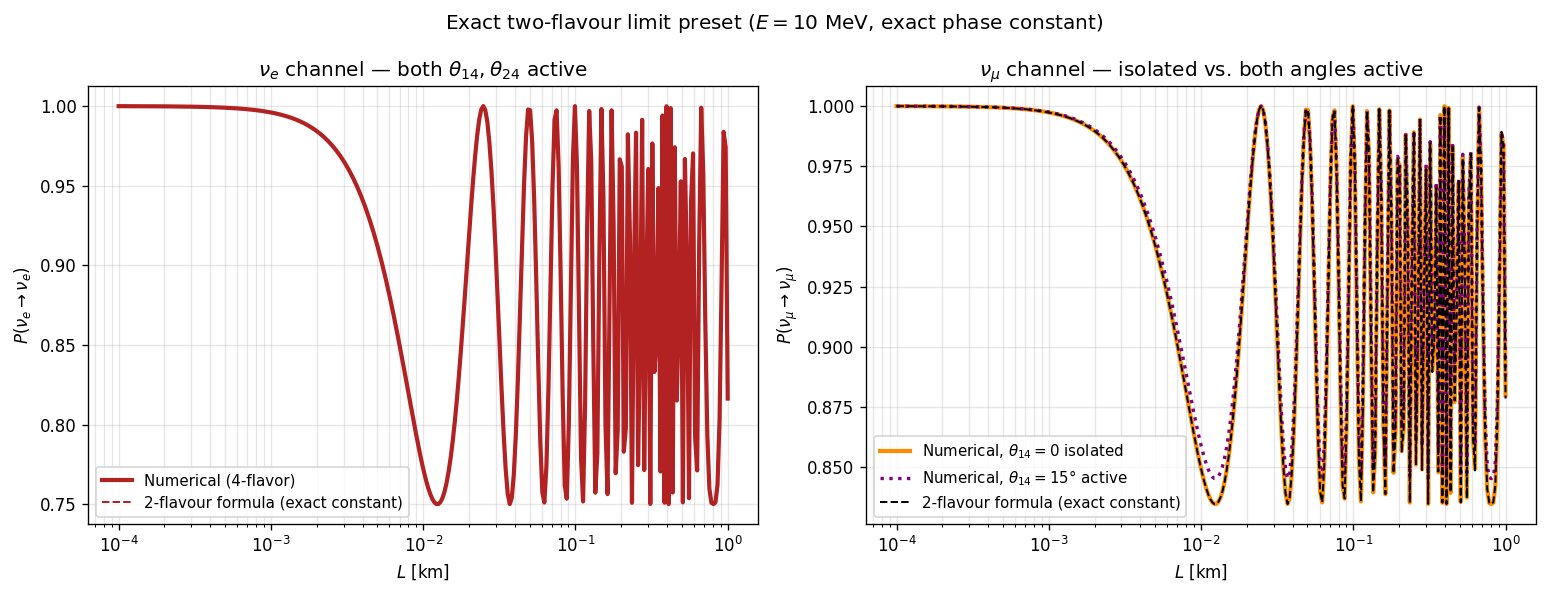

v:\output\analysis\bsm\k_fig3_exact_limit.png
                      Check  max |P_num - P_analytic|                               Expected
  nu_e (both angles active)                  1.03e-14                    ~0 (floating point)
nu_mu (theta14=0, isolated)                  1.41e-03             small: mass-hierarchy only
 nu_mu (both angles active)                  1.07e-02 small: mass-hierarchy + R14/R24 mixing


In [5]:
th14_c = float(osc_clean.pmns.sterile_params.theta14)
th24_c = float(osc_clean.pmns.sterile_params.theta24)
Dm41_c = float(osc_clean.mass_spectrum.DeltamSq41)

E_MeV = 10.0
L_km  = np.logspace(-4, 0, 300)
L_t   = torch.tensor(L_km, dtype=context.dtype, device=context.device)
E_t   = torch.tensor(E_MeV, dtype=context.dtype, device=context.device)
phase_exact = EXACT_PHASE_CONST * Dm41_c * L_km / E_MeV

# --- Check 1: nu_e channel, exact formula, both angles active in the preset ---
P_nue_num    = torch.stack([vac_prob_4nu(osc_clean, E_t, L_t[i])[0, 0] for i in range(len(L_km))]).cpu().numpy()
P_nue_analyt = 1 - math.sin(2 * th14_c) ** 2 * np.sin(phase_exact) ** 2
max_err_nue_exact = float(np.abs(P_nue_num - P_nue_analyt).max())

# --- Check 2: nu_mu channel, isolated (theta14 forced to 0) ---
sp_mu_only   = PMNSSterileParams(theta14=0.0, theta24=th24_c, theta34=0.0,
                                  delta14=0.0, delta24=0.0, delta34=0.0, context=context)
pmns_mu_only = PMNS_sterile(osc_clean.pmns.params, sp_mu_only)
osc_mu_only  = dataclasses.replace(osc_clean, pmns=pmns_mu_only)
P_numu_isolated    = torch.stack([vac_prob_4nu(osc_mu_only, E_t, L_t[i])[1, 1] for i in range(len(L_km))]).cpu().numpy()
P_numu_analyt      = 1 - math.sin(2 * th24_c) ** 2 * np.sin(phase_exact) ** 2
max_err_numu_isolated = float(np.abs(P_numu_isolated - P_numu_analyt).max())

# --- Check 3: nu_mu channel, both angles active (preset as registered) ---
P_numu_full     = torch.stack([vac_prob_4nu(osc_clean, E_t, L_t[i])[1, 1] for i in range(len(L_km))]).cpu().numpy()
max_err_numu_full = float(np.abs(P_numu_full - P_numu_analyt).max())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.semilogx(L_km, P_nue_num,    color="firebrick", lw=2.5, label="Numerical (4-flavor)")
ax.semilogx(L_km, P_nue_analyt, color="firebrick", lw=1.2, ls="--", label="2-flavour formula (exact constant)")
ax.set_xlabel(r"$L$ [km]"); ax.set_ylabel(r"$P(\nu_e\to\nu_e)$")
ax.set_title(r"$\nu_e$ channel — both $\theta_{14},\theta_{24}$ active")
ax.legend(fontsize=9); ax.grid(True, which="both", alpha=0.3)

ax = axes[1]
ax.semilogx(L_km, P_numu_isolated, color="darkorange", lw=2.5, label=r"Numerical, $\theta_{14}=0$ isolated")
ax.semilogx(L_km, P_numu_full,     color="purple",     lw=2.0, ls=":", label=r"Numerical, $\theta_{14}=15°$ active")
ax.semilogx(L_km, P_numu_analyt,   color="black",      lw=1.2, ls="--", label="2-flavour formula (exact constant)")
ax.set_xlabel(r"$L$ [km]"); ax.set_ylabel(r"$P(\nu_\mu\to\nu_\mu)$")
ax.set_title(r"$\nu_\mu$ channel — isolated vs. both angles active")
ax.legend(fontsize=9); ax.grid(True, which="both", alpha=0.3)

fig.suptitle(rf"Exact two-flavour limit preset ($E={E_MeV:.0f}$ MeV, exact phase constant)", fontsize=12)
fig.tight_layout()
save_and_show("k_fig3_exact_limit.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

table3 = pd.DataFrame([
    {"Check": "nu_e (both angles active)",      "max |P_num - P_analytic|": max_err_nue_exact,     "Expected": "~0 (floating point)"},
    {"Check": "nu_mu (theta14=0, isolated)",     "max |P_num - P_analytic|": max_err_numu_isolated, "Expected": "small: mass-hierarchy only"},
    {"Check": "nu_mu (both angles active)",      "max |P_num - P_analytic|": max_err_numu_full,      "Expected": "small: mass-hierarchy + R14/R24 mixing"},
])
print(table3.to_string(index=False, float_format=lambda x: f"{x:.2e}"))

## 4. Two-Flavour Approximation at Realistic Mixing

The same comparison as Section 3, now at the realistic mixing angles used elsewhere in
the series: `sterile_3p1_bestfit_giunti2017` ($\theta_{14}=8.5°,\theta_{24}=7.5°$, both
active-sector angles at their NuFIT 5.2 values) for the $\nu_e$ channel, and
`sterile_3p1_benchmark_icecube` ($\theta_{24}=9.22°$) for the $\nu_\mu$ channel. Here
the standard rounded $1.267$ constant is used (matching the literature convention), since
the rounding effect quantified in Section 3 ($\lesssim10^{-3}$) is negligible next to
the mixing-amplitude effect being quantified below.

**Expected results:**
- **$\nu_e$ (Giunti 2017):** $\theta_{24}$ has *no* effect on $P_{ee}$ at all (Section
  0.2); the deviation comes entirely from
  $|U_{e4}|^2=\cos^2\theta_{12}\cos^2\theta_{13}\sin^2\theta_{14}\approx0.0149$ vs. the
  naive $\sin^2\theta_{14}\approx0.0218$. The *predicted* deviation
  ($\sin^2(2\theta_{14})-4|U_{e4}|^2(1-|U_{e4}|^2)$) should match the *observed* maximum
  numerical deviation almost exactly, since the electron channel reduces to an exact
  2-state system (Section 3).
- **$\nu_\mu$ (IceCube 2020):** $\theta_{14}=0$ here, but $\theta_{23}=49°$ (NuFIT) is
  *not* zero, so $|U_{\mu4}|^2$ still deviates substantially from $\sin^2\theta_{24}$.
  Unlike the electron channel, $\mu$ is *not* an exact 2-state system (states 1, 2, and
  3 are all populated with comparable weight), so the simple
  $4|U_{\mu4}|^2(1-|U_{\mu4}|^2)$ substitution captures the dominant part of the
  deviation but not all of it — expect the *observed* deviation to somewhat exceed the
  *predicted* one, reflecting genuine residual active-sector phase structure beyond the
  2-state reduction.

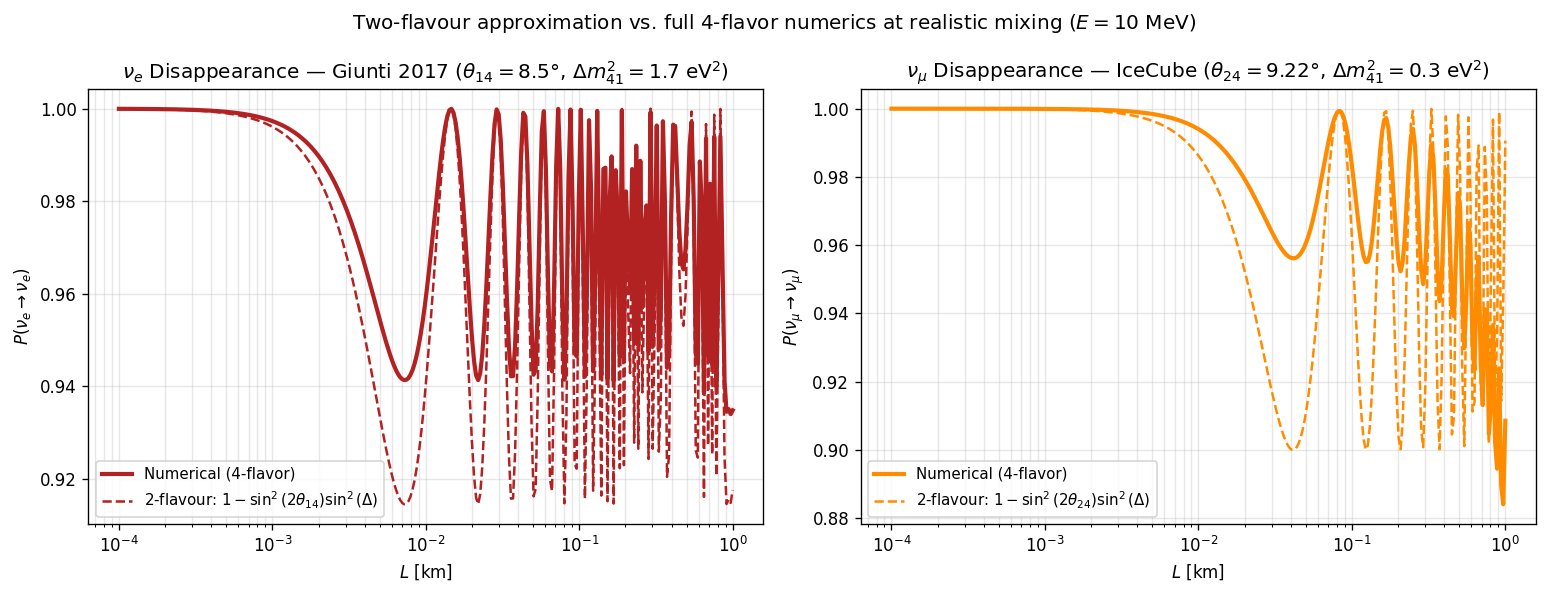

v:\output\analysis\bsm\k_fig4_realistic_mixing.png
             Channel  |U_a4|^2 naive  |U_a4|^2 exact  amp naive  amp exact  predicted max dev  observed max dev
  nu_e (Giunti 2017)          0.0218          0.0149     0.0855     0.0587             0.0268            0.0268
nu_mu (IceCube 2020)          0.0257          0.0110     0.1000     0.0437             0.0563            0.0821


In [6]:
E_MeV = 10.0

# --- nu_e channel: Giunti 2017 ---
L_km  = np.logspace(-4, 0, 300)
L_t   = torch.tensor(L_km, dtype=context.dtype, device=context.device)
E_t   = torch.tensor(E_MeV, dtype=context.dtype, device=context.device)

th14_g = float(osc_giunti.pmns.sterile_params.theta14)
Dm41_g = float(osc_giunti.mass_spectrum.DeltamSq41)
P_nue_num    = torch.stack([vac_prob_4nu(osc_giunti, E_t, L_t[i])[0, 0] for i in range(len(L_km))]).cpu().numpy()
phase_g      = PHASE_CONST_LITERATURE * Dm41_g * L_km / E_MeV
P_nue_analyt = 1 - math.sin(2 * th14_g) ** 2 * np.sin(phase_g) ** 2
max_err_nue_realistic = float(np.abs(P_nue_num - P_nue_analyt).max())

th12_g, th13_g = float(osc_giunti.pmns.params.theta12), float(osc_giunti.pmns.params.theta13)
Ue4_sq_naive = math.sin(th14_g) ** 2
Ue4_sq_exact = math.cos(th12_g) ** 2 * math.cos(th13_g) ** 2 * math.sin(th14_g) ** 2
amp_naive_e  = math.sin(2 * th14_g) ** 2
amp_exact_e  = 4 * Ue4_sq_exact * (1 - Ue4_sq_exact)
pred_dev_e   = amp_naive_e - amp_exact_e

# --- nu_mu channel: IceCube 2020 benchmark ---
th24_ic = float(osc_ic.pmns.sterile_params.theta24)
Dm41_ic = float(osc_ic.mass_spectrum.DeltamSq41)
P_numu_num    = torch.stack([vac_prob_4nu(osc_ic, E_t, L_t[i])[1, 1] for i in range(len(L_km))]).cpu().numpy()
phase_ic      = PHASE_CONST_LITERATURE * Dm41_ic * L_km / E_MeV
P_numu_analyt = 1 - math.sin(2 * th24_ic) ** 2 * np.sin(phase_ic) ** 2
max_err_numu_realistic = float(np.abs(P_numu_num - P_numu_analyt).max())

U_ic = osc_ic.pmns.pmns_matrix()
Umu4_sq_naive = math.sin(th24_ic) ** 2
Umu4_sq_exact = float((U_ic[1, 3].abs() ** 2).item())
amp_naive_mu  = math.sin(2 * th24_ic) ** 2
amp_exact_mu  = 4 * Umu4_sq_exact * (1 - Umu4_sq_exact)
pred_dev_mu   = amp_naive_mu - amp_exact_mu

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.semilogx(L_km, P_nue_num,    color="firebrick", lw=2.5, label="Numerical (4-flavor)")
ax.semilogx(L_km, P_nue_analyt, color="firebrick", lw=1.5, ls="--", label=r"2-flavour: $1-\sin^2(2\theta_{14})\sin^2(\Delta)$")
ax.set_xlabel(r"$L$ [km]"); ax.set_ylabel(r"$P(\nu_e\to\nu_e)$")
ax.set_title(r"$\nu_e$ Disappearance — Giunti 2017 ($\theta_{14}=8.5°$, $\Delta m^2_{41}=1.7$ eV$^2$)")
ax.legend(fontsize=9); ax.grid(True, which="both", alpha=0.3)

ax = axes[1]
ax.semilogx(L_km, P_numu_num,    color="darkorange", lw=2.5, label="Numerical (4-flavor)")
ax.semilogx(L_km, P_numu_analyt, color="darkorange", lw=1.5, ls="--", label=r"2-flavour: $1-\sin^2(2\theta_{24})\sin^2(\Delta)$")
ax.set_xlabel(r"$L$ [km]"); ax.set_ylabel(r"$P(\nu_\mu\to\nu_\mu)$")
ax.set_title(r"$\nu_\mu$ Disappearance — IceCube ($\theta_{24}=9.22°$, $\Delta m^2_{41}=0.3$ eV$^2$)")
ax.legend(fontsize=9); ax.grid(True, which="both", alpha=0.3)

fig.suptitle(rf"Two-flavour approximation vs. full 4-flavor numerics at realistic mixing ($E={E_MeV:.0f}$ MeV)", fontsize=12)
fig.tight_layout()
save_and_show("k_fig4_realistic_mixing.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

table4 = pd.DataFrame([
    {"Channel": "nu_e (Giunti 2017)",  "|U_a4|^2 naive": Ue4_sq_naive,  "|U_a4|^2 exact": Ue4_sq_exact,
     "amp naive": amp_naive_e,  "amp exact": amp_exact_e,  "predicted max dev": pred_dev_e,  "observed max dev": max_err_nue_realistic},
    {"Channel": "nu_mu (IceCube 2020)", "|U_a4|^2 naive": Umu4_sq_naive, "|U_a4|^2 exact": Umu4_sq_exact,
     "amp naive": amp_naive_mu, "amp exact": amp_exact_mu, "predicted max dev": pred_dev_mu, "observed max dev": max_err_numu_realistic},
])
print(table4.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

## 5. L/E Sensitivity Window

The oscillation maximum occurs at $L/E \approx \pi / (2\times1.267\times\Delta m^2_{41})$
km/GeV. Different values of $\Delta m^2_{41}$ require different experimental baselines
and energies. This section shows $P(\nu_e\to\nu_e; L, E)$ as a heatmap (2-flavour
approximation, $\theta_{14}$ fixed at the Giunti 2017 value) for three representative
$\Delta m^2_{41}$ values, marking where each experiment from Section 0.3 sits.

**Expected results:** As $\Delta m^2_{41}$ increases, the oscillation maximum shifts
to shorter $L/E$. At $\Delta m^2_{41}=1.7\ \text{eV}^2$ the first maximum is at
$L/E\approx0.37\ \text{m/MeV}$, matching the short-baseline reactor/Gallium regime.

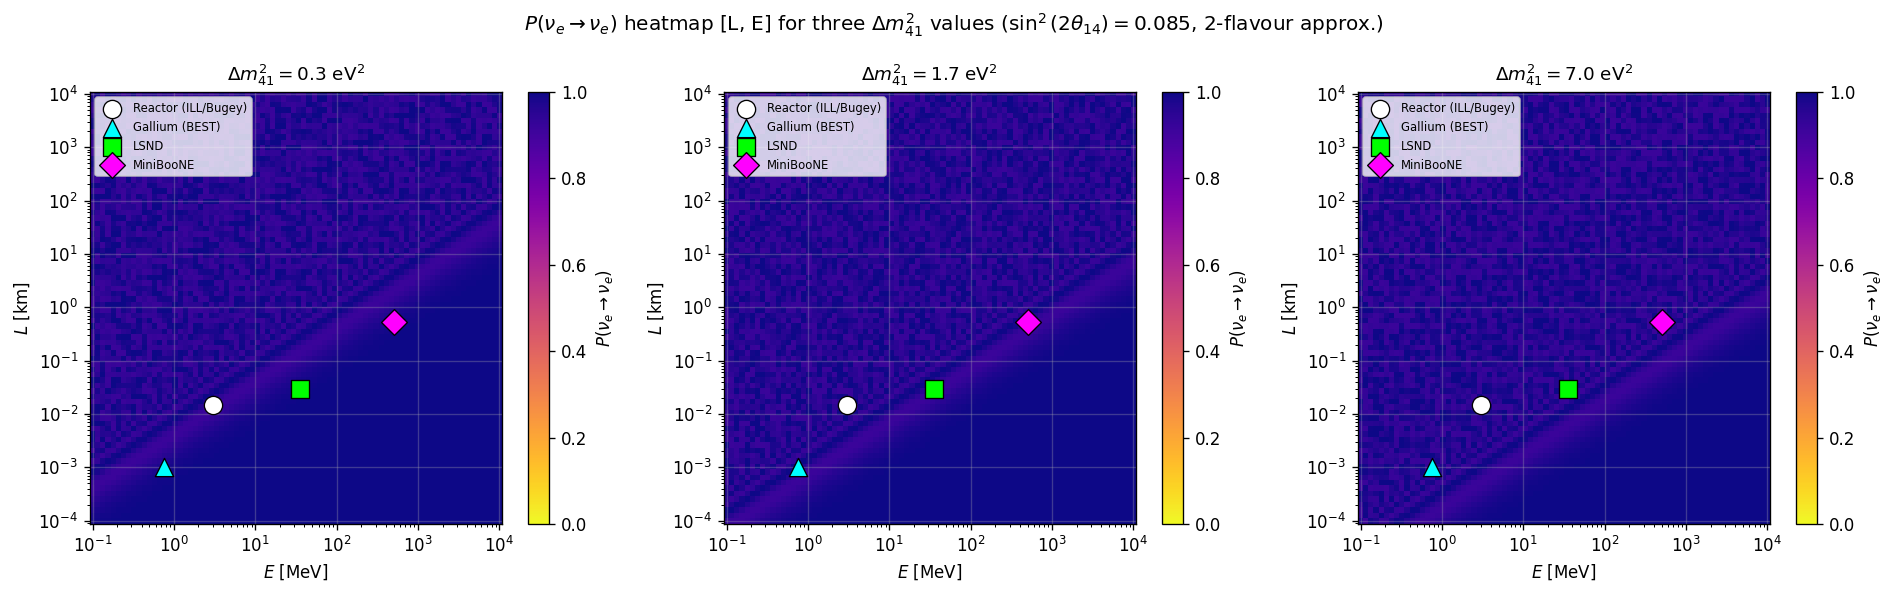

v:\output\analysis\bsm\k_fig5_le_window.png
  Dm41 = 0.3 eV^2 -> (L/E)_max = 0.0041 km/MeV = 4.13 m/MeV
  Dm41 = 1.7 eV^2 -> (L/E)_max = 0.0007 km/MeV = 0.73 m/MeV
  Dm41 = 7.0 eV^2 -> (L/E)_max = 0.0002 km/MeV = 0.18 m/MeV


In [7]:
Dm41_vals   = [0.3, 1.7, 7.0]
Dm41_labels = [r"$\Delta m^2_{41}=0.3$ eV$^2$", r"$\Delta m^2_{41}=1.7$ eV$^2$", r"$\Delta m^2_{41}=7.0$ eV$^2$"]

E_arr = np.logspace(-1, 4, 80)   # MeV: 0.1 MeV to 10 TeV
L_arr = np.logspace(-4, 4, 80)   # km:  1 m to 10000 km
EE, LL = np.meshgrid(E_arr, L_arr)

th14 = float(osc_giunti.pmns.sterile_params.theta14)
A14  = math.sin(2 * th14) ** 2

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, Dm41, title in zip(axes, Dm41_vals, Dm41_labels):
    phase = PHASE_CONST_LITERATURE * Dm41 * LL / EE
    P_hm  = 1 - A14 * np.sin(phase) ** 2

    im = ax.pcolormesh(EE, LL, P_hm, cmap="plasma_r", vmin=0, vmax=1, shading="auto")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(r"$E$ [MeV]"); ax.set_ylabel(r"$L$ [km]")
    ax.set_title(title, fontsize=11)
    fig.colorbar(im, ax=ax, label=r"$P(\nu_e\to\nu_e)$")

    exps = {
        "Reactor (ILL/Bugey)": (3.0,  0.015,  "w", "o"),
        "Gallium (BEST)":      (0.75, 0.001,  "cyan", "^"),
        "LSND":                (35.0, 0.030,  "lime", "s"),
        "MiniBooNE":           (500., 0.541,  "magenta", "D"),
        "IceCube":             (1e6,  1.27e4, "yellow", "*"),
    }
    for name, (E0, L0, col, mk) in exps.items():
        if E_arr[0] <= E0 <= E_arr[-1] and L_arr[0] <= L0 <= L_arr[-1]:
            ax.scatter(E0, L0, color=col, marker=mk, s=120, zorder=5,
                       edgecolors="black", linewidths=0.8, label=name)
    ax.legend(fontsize=7, loc="upper left")

fig.suptitle(
    rf"$P(\nu_e\to\nu_e)$ heatmap [L, E] for three $\Delta m^2_{{41}}$ values "
    rf"($\sin^2(2\theta_{{14}})={A14:.3f}$, 2-flavour approx.)", fontsize=12,
)
fig.tight_layout()
save_and_show("k_fig5_le_window.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

for Dm41 in Dm41_vals:
    LE_max = math.pi / (2 * PHASE_CONST_LITERATURE * Dm41)  # km/MeV
    print(f"  Dm41 = {Dm41:.1f} eV^2 -> (L/E)_max = {LE_max:.4f} km/MeV = {LE_max*1e3:.2f} m/MeV")

## Summary

| Check | Result | Interpretation |
|---|---|---|
| $\nu_e$, exact limit ($\theta_{12}=\theta_{13}=0$) | $\sim10^{-14}$ | Floating point — no approximation needed at all |
| $\nu_\mu$, exact limit, isolated ($\theta_{14}=0$) | $\sim10^{-3}$ | Pure mass-hierarchy ("one mass-scale dominance") residual |
| $\nu_\mu$, exact limit, both angles active | $\sim10^{-2}$ | Mass-hierarchy + $R_{14}/R_{24}$ non-commutation |
| $\nu_e$, realistic (Giunti 2017) | predicted $\approx$ observed ($\approx0.027$) | Fully explained by $\lvert U_{e4}\rvert^2$ convention |
| $\nu_\mu$, realistic (IceCube 2020) | observed $>$ predicted ($0.082$ vs. $0.056$) | Convention effect dominant; residual active-sector structure not captured by the 2-state reduction |

**Key conclusions:**

1. The 2-flavour disappearance formula is provably **exact** for the $\nu_e$ channel
   whenever the active mixing angles $\theta_{12},\theta_{13}$ vanish, for *any*
   $\theta_{24}$ — because $\theta_{24}$ has zero effect on $P_{ee}$ and the electron
   flavour reduces to an exact 2-state (1,4) system in that limit.
2. The "one mass-scale dominance" mass-splitting approximation
   ($\Delta m^2_{41}\gg\Delta m^2_{31},\Delta m^2_{21}$) is excellent on its own
   ($\lesssim10^{-3}$ residual) across every experiment in this series — it is *not*
   the dominant source of deviation seen at realistic mixing angles.
3. At realistic mixing angles, the dominant deviation comes from tpeanuts' rotation
   ordering giving $\lvert U_{e4}\rvert^2=\cos^2\theta_{12}\cos^2\theta_{13}\sin^2\theta_{14}$
   rather than the bare $\sin^2\theta_{14}$ the textbook formula assumes — a
   convention-dependent effect, fully predictable and quantified in Section 4's table.
4. The $\nu_\mu$ channel is structurally different: it is never an exact 2-state system
   at realistic mixing (all three active states are comparably populated), so its
   deviation from the 2-flavour formula is only partially captured by the
   $\lvert U_{\mu4}\rvert^2$ substitution.
5. Real experiments span more than 9 decades in $L/E$ (Gallium at $\sim10^{-3}$ m/MeV to
   IceCube at $\sim10$ m/MeV): the $\Delta m^2_{41}\sim0.3$–1.7 eV$^2$ range considered
   throughout this series places the oscillation maximum squarely in the
   reactor/Gallium/LSND regime, while IceCube probes deep in the many-oscillations
   averaged-out regime at TeV energies.

**Next:** `sterile3_analysis.ipynb` confronts these same presets with real experimental
data (reactor, Gallium, LSND/MiniBooNE, IceCube) and quantifies the global
appearance-vs-disappearance tension of the minimal 3+1 model.

In [8]:
print("=== sterile2_kinematics.ipynb -- Summary ===")
print()
print("Section 3 -- exact two-flavour limit (exact phase constant):")
print(f"  nu_e  (both angles active)      : max err = {max_err_nue_exact:.2e}")
print(f"  nu_mu (theta14=0, isolated)     : max err = {max_err_numu_isolated:.2e}")
print(f"  nu_mu (both angles active)      : max err = {max_err_numu_full:.2e}")
print()
print("Section 4 -- realistic mixing (literature 1.267 constant):")
print(f"  nu_e  (Giunti 2017)  : predicted dev = {pred_dev_e:.4f}   observed dev = {max_err_nue_realistic:.4f}")
print(f"  nu_mu (IceCube 2020) : predicted dev = {pred_dev_mu:.4f}   observed dev = {max_err_numu_realistic:.4f}")

=== sterile2_kinematics.ipynb -- Summary ===

Section 3 -- exact two-flavour limit (exact phase constant):
  nu_e  (both angles active)      : max err = 1.03e-14
  nu_mu (theta14=0, isolated)     : max err = 1.41e-03
  nu_mu (both angles active)      : max err = 1.07e-02

Section 4 -- realistic mixing (literature 1.267 constant):
  nu_e  (Giunti 2017)  : predicted dev = 0.0268   observed dev = 0.0268
  nu_mu (IceCube 2020) : predicted dev = 0.0563   observed dev = 0.0821
